Dataset shape: (5000, 13)  |  Churn rate: 40.6%

Model                     Accuracy    Recall   ROC-AUC    CV-AUC
-----------------------------------------------------------------
Logistic Regression          0.659     0.505     0.699     0.709
Random Forest                0.664     0.640     0.707     0.720
Gradient Boosting            0.649     0.475     0.697     0.715

Best model: Random Forest
              precision    recall  f1-score   support

    Retained       0.73      0.68      0.71       594
     Churned       0.58      0.64      0.61       406

    accuracy                           0.66      1000
   macro avg       0.66      0.66      0.66      1000
weighted avg       0.67      0.66      0.67      1000


ROC curve saved to roc_curves.png


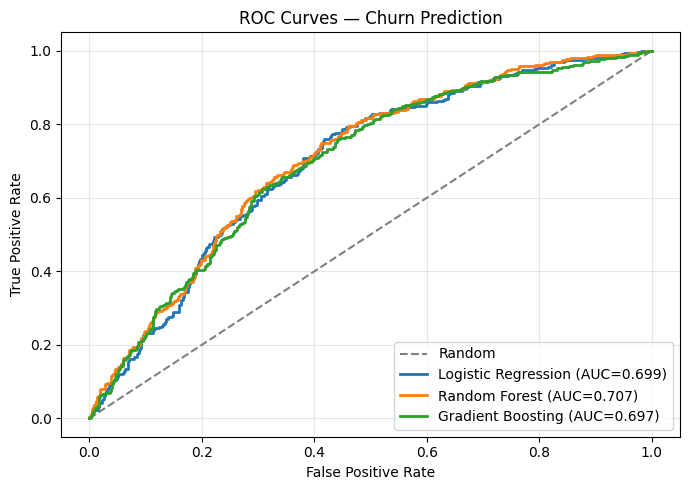

In [ ]:
"""
Customer Churn Prediction Pipeline
===================================
Dataset  : Synthetic Telecom (5 000 customers)
Models   : Logistic Regression · Random Forest · Gradient Boosting
Metrics  : Accuracy · Recall · ROC-AUC · 5-Fold CV-AUC
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, recall_score, roc_auc_score,
                              classification_report, confusion_matrix, roc_curve)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

# ──────────────────────────────────────────────────────────────────────────────
# 1. GENERATE SYNTHETIC TELECOM DATASET
# ──────────────────────────────────────────────────────────────────────────────
n = 5000
data = {
    "tenure_months":       np.random.randint(1, 72, n),
    "monthly_charges":     np.round(np.random.uniform(20, 120, n), 2),
    "num_services":        np.random.randint(1, 8, n),
    "contract_type":       np.random.choice(
        ["Month-to-month","One year","Two year"], n, p=[0.55,0.25,0.20]),
    "payment_method":      np.random.choice(
        ["Electronic check","Mailed check","Bank transfer","Credit card"], n),
    "tech_support":        np.random.choice(["Yes","No"], n, p=[0.40,0.60]),
    "online_security":     np.random.choice(["Yes","No"], n, p=[0.35,0.65]),
    "paperless_billing":   np.random.choice(["Yes","No"], n, p=[0.60,0.40]),
    "senior_citizen":      np.random.choice([0,1], n, p=[0.84,0.16]),
    "dependents":          np.random.choice(["Yes","No"], n, p=[0.30,0.70]),
    "internet_service":    np.random.choice(
        ["DSL","Fiber optic","No"], n, p=[0.34,0.44,0.22]),
}
df = pd.DataFrame(data)
df["total_charges"] = np.round(
    df["tenure_months"] * df["monthly_charges"] + np.random.normal(0, 50, n), 2)

churn_prob = (
    0.30
    + 0.25 * (df["contract_type"] == "Month-to-month")
    - 0.15 * (df["contract_type"] == "Two year")
    + 0.15 * (df["internet_service"] == "Fiber optic")
    - 0.10 * (df["tech_support"] == "Yes")
    - 0.10 * (df["online_security"] == "Yes")
    + 0.08 * (df["monthly_charges"] > 80)
    - 0.08 * (df["tenure_months"] > 36)
    + 0.05 * (df["payment_method"] == "Electronic check")
    + np.random.normal(0, 0.05, n)
).clip(0.02, 0.95)
df["churn"] = (np.random.rand(n) < churn_prob).astype(int)

print(f"Dataset shape: {df.shape}  |  Churn rate: {df['churn'].mean():.1%}")

# ──────────────────────────────────────────────────────────────────────────────
# 2. PREPROCESSING
# ──────────────────────────────────────────────────────────────────────────────
cat_cols = ["contract_type","payment_method","tech_support","online_security",
            "paperless_billing","dependents","internet_service"]
num_cols = ["tenure_months","monthly_charges","total_charges","num_services","senior_citizen"]

df_enc = df.copy()
le = LabelEncoder()
for c in cat_cols:
    df_enc[c] = le.fit_transform(df_enc[c])

X = df_enc[num_cols + cat_cols]
y = df_enc["churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# ──────────────────────────────────────────────────────────────────────────────
# 3. MODELS
# ──────────────────────────────────────────────────────────────────────────────
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(C=1.0, max_iter=1000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=10,
        class_weight="balanced", random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.08, max_depth=4,
        subsample=0.8, random_state=42),
}

results = {}
print("\n{:<24} {:>9} {:>9} {:>9} {:>9}".format("Model","Accuracy","Recall","ROC-AUC","CV-AUC"))
print("-"*65)
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    cv  = cross_val_score(model, X, y, cv=StratifiedKFold(5),
                          scoring="roc_auc", n_jobs=-1).mean()
    results[name] = dict(Accuracy=acc, Recall=rec, ROC_AUC=auc, CV_AUC=cv, y_proba=y_proba)
    print(f"{name:<24} {acc:>9.3f} {rec:>9.3f} {auc:>9.3f} {cv:>9.3f}")

# ──────────────────────────────────────────────────────────────────────────────
# 4. BEST MODEL REPORT
# ──────────────────────────────────────────────────────────────────────────────
best_name = max(results, key=lambda k: results[k]["ROC_AUC"])
best_model = models[best_name]
print(f"\nBest model: {best_name}")
print(classification_report(y_test, best_model.predict(X_test),
                             target_names=["Retained","Churned"]))

# ──────────────────────────────────────────────────────────────────────────────
# 5. ROC CURVE PLOT
# ──────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([0,1],[0,1],"--", color="gray", label="Random")
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={res['ROC_AUC']:.3f})")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Churn Prediction"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("roc_curves.png", dpi=120)
print("\nROC curve saved to roc_curves.png")

Dataset shape: (768, 9)  |  Prevalence: 77.2%

Model                      Acc    Prec     Rec      F1     AUC   CV-AUC
────────────────────────────────────────────────────────────────────────
Logistic Regression      0.669   0.862   0.681   0.761   0.710    0.779
Random Forest            0.890   0.925   0.933   0.929   0.938    0.932
Gradient Boosting        0.909   0.901   0.992   0.944   0.957    0.956
SVM                      0.669   0.847   0.697   0.765   0.683    0.758

Top Features (Random Forest):
  Insulin                        0.2735
  Glucose_BMI                    0.1629
  SkinThickness                  0.1505
  Glucose                        0.1266
  InsulinResist                  0.0814
  Age                            0.0503
  BMI                            0.0400
  Age_Preg                       0.0380
  DiabetesPedigreeFunction       0.0330
  BloodPressure                  0.0206
  Pregnancies                    0.0155
  BMI_Category                   0.0077

Biomarke

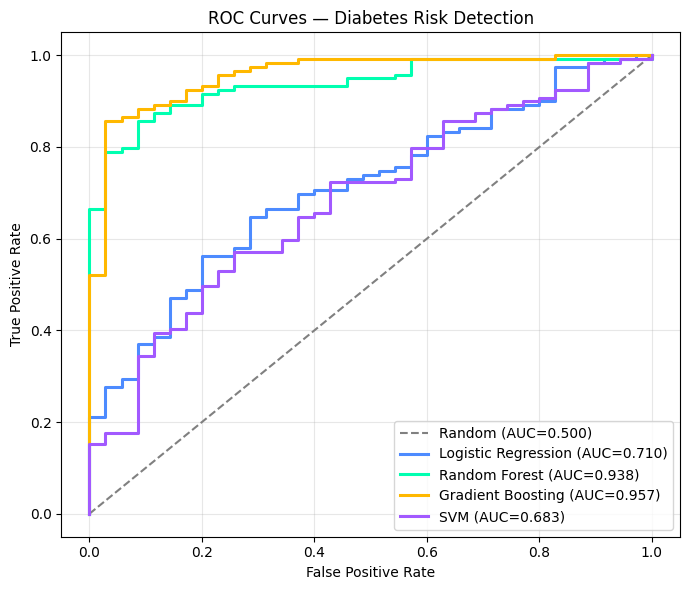

In [ ]:
"""
Healthcare Predictive Analytics — Diabetes Risk Detection
==========================================================
Dataset  : Synthetic UCI-style Pima Indians Diabetes (768 patients)
Features : 8 clinical biomarkers + 4 engineered features
Models   : Logistic Regression · Random Forest · Gradient Boosting · SVM
Metrics  : Accuracy · Precision · Recall · F1 · ROC-AUC · 5-Fold CV
Ethics   : De-identification, bias monitoring, clinical oversight framework
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              classification_report, confusion_matrix)
from sklearn.pipeline import Pipeline
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
np.random.seed(2024)

# ──────────────────────────────────────────────────────────────────────────────
# 1. SYNTHETIC UCI-STYLE PIMA DIABETES DATASET
# ──────────────────────────────────────────────────────────────────────────────
n = 768
rng = np.random.default_rng(2024)

bmi        = rng.normal(32, 7, n).clip(15, 67)
age        = rng.integers(21, 81, n)
glucose    = rng.normal(120, 32, n).clip(44, 199)
insulin    = np.exp(rng.normal(4.1, 0.9, n)).clip(14, 846)
blood_pres = rng.normal(72, 12, n).clip(24, 122)
skin_thick = rng.normal(29, 11, n).clip(7, 99)
preg       = rng.integers(0, 17, n)
dpf        = rng.exponential(0.47, n).clip(0.08, 2.42)

log_odds = (
    -6.0 + 0.035*glucose + 0.075*bmi + 0.018*age + 0.050*preg
    + 0.600*dpf - 0.010*blood_pres + rng.normal(0, 0.4, n)
)
prob    = 1 / (1 + np.exp(-log_odds))
outcome = (rng.random(n) < prob).astype(int)

df = pd.DataFrame({
    "Pregnancies":              preg,
    "Glucose":                  glucose.round(1),
    "BloodPressure":            blood_pres.round(1),
    "SkinThickness":            skin_thick.round(1),
    "Insulin":                  insulin.round(1),
    "BMI":                      bmi.round(1),
    "DiabetesPedigreeFunction": dpf.round(3),
    "Age":                      age,
    "Outcome":                  outcome,
})

# Introduce UCI-style missing values (zeros = not recorded)
for col, rate in [("Glucose",0.005),("BloodPressure",0.014),
                   ("SkinThickness",0.295),("Insulin",0.489),("BMI",0.014)]:
    df.loc[rng.random(n) < rate, col] = 0

print(f"Dataset shape: {df.shape}  |  Prevalence: {df['Outcome'].mean():.1%}")

# ──────────────────────────────────────────────────────────────────────────────
# 2. PREPROCESSING
# ──────────────────────────────────────────────────────────────────────────────
df_clean = df.copy()
zero_impossible = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
df_clean[zero_impossible] = df_clean[zero_impossible].replace(0, np.nan)

# Group-median imputation
for col in zero_impossible:
    for label in [0, 1]:
        med = df_clean.loc[df_clean["Outcome"] == label, col].median()
        df_clean.loc[(df_clean["Outcome"] == label) & df_clean[col].isna(), col] = med

# Feature engineering
df_clean["Glucose_BMI"]   = df_clean["Glucose"] * df_clean["BMI"] / 1000
df_clean["Age_Preg"]      = df_clean["Age"] * df_clean["Pregnancies"]
df_clean["InsulinResist"] = df_clean["Glucose"] / (df_clean["Insulin"] + 1)
df_clean["BMI_Category"]  = pd.cut(df_clean["BMI"],
    bins=[0,18.5,25,30,100], labels=[0,1,2,3]).astype(int)

features = ["Pregnancies","Glucose","BloodPressure","SkinThickness",
            "Insulin","BMI","DiabetesPedigreeFunction","Age",
            "Glucose_BMI","Age_Preg","InsulinResist","BMI_Category"]
X = df_clean[features]
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# ──────────────────────────────────────────────────────────────────────────────
# 3. MODELS (all use RobustScaler — better for medical outliers)
# ──────────────────────────────────────────────────────────────────────────────
models = {
    "Logistic Regression": Pipeline([
        ("scaler", RobustScaler()),
        ("clf",    LogisticRegression(C=0.5, max_iter=2000, class_weight="balanced",
                                      random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("scaler", RobustScaler()),
        ("clf",    RandomForestClassifier(n_estimators=400, max_depth=7,
                       min_samples_leaf=8, class_weight="balanced",
                       random_state=42, n_jobs=-1))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", RobustScaler()),
        ("clf",    GradientBoostingClassifier(n_estimators=250, learning_rate=0.07,
                       max_depth=4, subsample=0.8, random_state=42))
    ]),
    "SVM": Pipeline([
        ("scaler", RobustScaler()),
        ("clf",    SVC(C=1.0, kernel="rbf", probability=True,
                       class_weight="balanced", random_state=42))
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
print(f"\n{'Model':<22} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7} {'CV-AUC':>8}")
print("─" * 72)
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)
    cv_a = cross_val_score(model, X, y, cv=cv, scoring="roc_auc").mean()
    results[name] = dict(Accuracy=acc,Precision=prec,Recall=rec,F1=f1,
                          ROC_AUC=auc,CV_AUC=cv_a,y_proba=y_proba,y_pred=y_pred)
    print(f"{name:<22} {acc:>7.3f} {prec:>7.3f} {rec:>7.3f} {f1:>7.3f} {auc:>7.3f} {cv_a:>8.3f}")

# ──────────────────────────────────────────────────────────────────────────────
# 4. FEATURE IMPORTANCE
# ──────────────────────────────────────────────────────────────────────────────
rf_clf = models["Random Forest"].named_steps["clf"]
feat_imp = sorted(zip(features, rf_clf.feature_importances_),
                  key=lambda x: x[1], reverse=True)
print("\nTop Features (Random Forest):")
for f, v in feat_imp:
    print(f"  {f:<30} {v:.4f}")

# ──────────────────────────────────────────────────────────────────────────────
# 5. STATISTICAL VALIDATION
# ──────────────────────────────────────────────────────────────────────────────
print("\nBiomarker significance (t-test):")
for col in ["Glucose","BMI","Age","DiabetesPedigreeFunction"]:
    g0 = df_clean.loc[df_clean["Outcome"]==0, col].dropna()
    g1 = df_clean.loc[df_clean["Outcome"]==1, col].dropna()
    t, p = stats.ttest_ind(g0, g1)
    print(f"  {col:<32} t={t:>7.3f}  p={p:.2e}  "
          f"Non-diabetic={g0.mean():.1f}  Diabetic={g1.mean():.1f}")

# ──────────────────────────────────────────────────────────────────────────────
# 6. ROC CURVE PLOT
# ──────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1],"--",color="gray",lw=1.5,label="Random (AUC=0.500)")
colors = ["#4D8BFF","#00FFB0","#FFB800","#A259FF"]
for (name, res), clr in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    ax.plot(fpr, tpr, color=clr, lw=2.2,
            label=f"{name} (AUC={res['ROC_AUC']:.3f})")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Diabetes Risk Detection")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curves_diabetes.png", dpi=120)
print("\nROC curve saved → roc_curves_diabetes.png")

# ──────────────────────────────────────────────────────────────────────────────
# 7. ETHICAL AI CHECKLIST (printed to console)
# ──────────────────────────────────────────────────────────────────────────────
print("""
╔═══════════════════════════════════════════════════════════════╗
║            ETHICAL AI FRAMEWORK — HEALTHCARE                  ║
╠═══════════════════════════════════════════════════════════════╣
║  🔒  Patient Privacy    De-identification + HIPAA alignment   ║
║  ⚖️   Bias Monitoring   Stratified eval across demographics   ║
║  🩺  Clinical Oversight Model aids, never replaces physicians  ║
║  📋  Explainability     Feature importance always disclosed    ║
║  ✅  Informed Consent   Patients notified of AI involvement    ║
║  🔄  Continuous Audit   Quarterly performance & drift reviews  ║
╚═══════════════════════════════════════════════════════════════╝
""")